# DATA CALLING

In [ ]:
!gdown --fuzzy "https://drive.google.com/file/d/1Cmdu88uou8b5bwuuWvYd1-rR3_3lXdyp/view?usp=drive_link"

Downloading...
From: https://drive.google.com/uc?id=1Cmdu88uou8b5bwuuWvYd1-rR3_3lXdyp
To: /content/data_cleaned.csv
100% 4.80M/4.80M [00:00<00:00, 31.9MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

In [ ]:
# Load CSV
dff = pd.read_csv('/content/data_cleaned.csv')
dff.head()


,Income,Age,Dependents,Occupation,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,...,Education,Miscellaneous,Desired_Savings_Percentage,Desired_Savings,Disposable_Income,Total_Expense,Expense_to_Income_Ratio,Essential_Ratio,Discretionary_Spending,Age_Group
0,44637.24964,49,0,Self_Employed,13391.174890,0.000000,2206.490129,6658.768341,2636.970696,1651.801726,...,0.000000,831.525120,13.890948,6200.537192,11265.627710,33371.62193,0.747618,0.598494,4019.511102,45-60
1,26858.59659,34,2,Retired,5371.719318,0.000000,869.522617,2818.444460,1543.018778,649.378103,...,1551.723167,564.235007,7.160376,1923.176434,9676.818733,17181.77786,0.639712,0.440201,2263.854847,25-35
2,50367.60508,35,1,Student,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,1513.814376,...,3160.026299,628.371220,13.997808,7050.360422,13891.450620,36476.15446,0.724199,0.520756,3865.492522,25-35
3,101455.60020,21,0,Self_Employed,15218.340040,6567.855801,3597.595115,12929.092170,6714.626751,3646.170425,...,0.000000,2077.547201,16.455440,13703.375070,37601.469090,63854.13116,0.629380,0.478609,8581.911867,<25
4,24875.28355,52,4,Professional,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,692.827225,...,1445.215694,515.510300,7.533982,1874.099434,6265.700532,18609.58302,0.748115,0.563599,1868.524377,45-60


# DATA LOADING

In [ ]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.

### MULAI CODE ###

dff.info()

### SELESAI CODE ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Income                      20000 non-null  float64
 1   Age                         20000 non-null  int64  
 2   Dependents                  20000 non-null  int64  
 3   Occupation                  20000 non-null  object 
 4   Rent                        20000 non-null  float64
 5   Loan_Repayment              20000 non-null  float64
 6   Insurance                   20000 non-null  float64
 7   Groceries                   20000 non-null  float64
 8   Transport                   20000 non-null  float64
 9   Eating_Out                  20000 non-null  float64
 10  Entertainment               20000 non-null  float64
 11  Utilities                   20000 non-null  float64
 12  Healthcare                  20000 non-null  float64
 13  Education                   200

In [ ]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe

### MULAI CODE ###

dff.describe().round(2)

### SELESAI CODE ###

,Income,Age,Dependents,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,...,Healthcare,Education,Miscellaneous,Desired_Savings_Percentage,Desired_Savings,Disposable_Income,Total_Expense,Expense_to_Income_Ratio,Essential_Ratio,Discretionary_Spending
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,...,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,38352.67,41.03,2.00,8319.97,1512.65,1323.80,4791.49,2484.39,1331.28,1320.57,...,1526.78,2258.33,756.34,9.69,4021.78,10435.82,27916.86,0.74,0.52,3408.19
std,27287.57,13.58,1.42,6117.21,2280.52,978.29,3431.30,1784.13,983.11,972.25,...,1099.43,2128.89,564.98,3.55,3890.43,8984.50,19390.63,0.09,0.08,2417.04
min,1301.19,18.00,0.00,235.37,0.00,30.00,154.08,81.23,39.44,45.42,...,53.50,0.00,20.50,5.00,0.00,-1512.07,988.43,0.49,0.35,127.94
25%,17604.88,29.00,1.00,3649.42,0.00,580.20,2165.43,1124.58,581.01,581.63,...,684.36,611.68,323.63,6.94,1224.93,3859.77,12874.90,0.67,0.46,1552.14
50%,30185.38,41.00,2.00,6402.75,0.00,1017.12,3741.09,1933.85,1029.11,1020.20,...,1189.20,1701.90,579.08,8.90,2155.36,7429.97,22258.04,0.73,0.52,2689.41
75%,51765.45,53.00,3.00,11263.94,2627.14,1787.16,6470.89,3360.60,1807.08,1790.10,...,2057.08,3311.71,1025.20,11.88,6216.31,14042.36,38140.34,0.80,0.58,4606.20
max,103006.30,64.00,4.00,22685.72,6567.86,3597.60,12929.09,6714.63,3646.17,3602.81,...,4116.16,7361.74,2077.55,19.28,13703.38,50824.80,79532.12,1.06,0.82,9326.53


In [ ]:
df.head().round(2)

,Expense_to_Income_Ratio,Disposable_Income,Desired_Savings_Percentage,Essential_Ratio,Discretionary_Spending
0,0.17,0.38,1.01,0.68,0.44
1,-0.67,0.22,-0.35,-0.65,-0.14
2,-0.01,0.63,1.03,0.02,0.39
3,-0.75,2.96,1.53,-0.33,1.93
4,0.17,-0.11,-0.28,0.38,-0.27


# TEST 2

In [ ]:
df2 = dff.copy()
df2.head()

,Income,Age,Dependents,Occupation,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,...,Education,Miscellaneous,Desired_Savings_Percentage,Desired_Savings,Disposable_Income,Total_Expense,Expense_to_Income_Ratio,Essential_Ratio,Discretionary_Spending,Age_Group
0,44637.24964,49,0,Self_Employed,13391.174890,0.000000,2206.490129,6658.768341,2636.970696,1651.801726,...,0.000000,831.525120,13.890948,6200.537192,11265.627710,33371.62193,0.747618,0.598494,4019.511102,45-60
1,26858.59659,34,2,Retired,5371.719318,0.000000,869.522617,2818.444460,1543.018778,649.378103,...,1551.723167,564.235007,7.160376,1923.176434,9676.818733,17181.77786,0.639712,0.440201,2263.854847,25-35
2,50367.60508,35,1,Student,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,1513.814376,...,3160.026299,628.371220,13.997808,7050.360422,13891.450620,36476.15446,0.724199,0.520756,3865.492522,25-35
3,101455.60020,21,0,Self_Employed,15218.340040,6567.855801,3597.595115,12929.092170,6714.626751,3646.170425,...,0.000000,2077.547201,16.455440,13703.375070,37601.469090,63854.13116,0.629380,0.478609,8581.911867,<25
4,24875.28355,52,4,Professional,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,692.827225,...,1445.215694,515.510300,7.533982,1874.099434,6265.700532,18609.58302,0.748115,0.563599,1868.524377,45-60


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import matplotlib.pyplot as plt

In [ ]:
df2['Disposable_Income_Ratio'] = df2['Disposable_Income'] / df2['Income']
df2['Loan_to_Income_Ratio'] = df2['Loan_Repayment'] / df2['Income']
df2['Discretionary_Ratio'] = df2['Discretionary_Spending'] / df2['Income']

In [ ]:
features_cluster = [
    'Expense_to_Income_Ratio',
    'Essential_Ratio',
    'Disposable_Income_Ratio',
    'Loan_to_Income_Ratio',
    'Discretionary_Ratio'
]

In [ ]:
X_cluster = df2[features_cluster].copy()
X_cluster.head()

,Expense_to_Income_Ratio,Essential_Ratio,Disposable_Income_Ratio,Loan_to_Income_Ratio,Discretionary_Ratio
0,0.747618,0.598494,0.252382,0.000000,0.090048
1,0.639712,0.440201,0.360288,0.000000,0.084288
2,0.724199,0.520756,0.275801,0.091569,0.076746
3,0.629380,0.478609,0.370620,0.064736,0.084588
4,0.748115,0.563599,0.251885,0.125129,0.075116


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

In [ ]:
X_scaled = pd.DataFrame(X_scaled, columns=features_cluster)
X_scaled.head()

,Expense_to_Income_Ratio,Essential_Ratio,Disposable_Income_Ratio,Loan_to_Income_Ratio,Discretionary_Ratio
0,0.106435,0.884352,-0.106435,-0.736112,0.035355
1,-1.058920,-0.988372,1.058920,-0.736112,-0.401416
2,-0.146490,-0.035347,0.146490,0.754665,-0.973290
3,-1.170507,-0.533974,1.170507,0.317820,-0.378673
4,0.111804,0.471517,-0.111804,1.301031,-1.096874


In [ ]:
inertia = []

k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

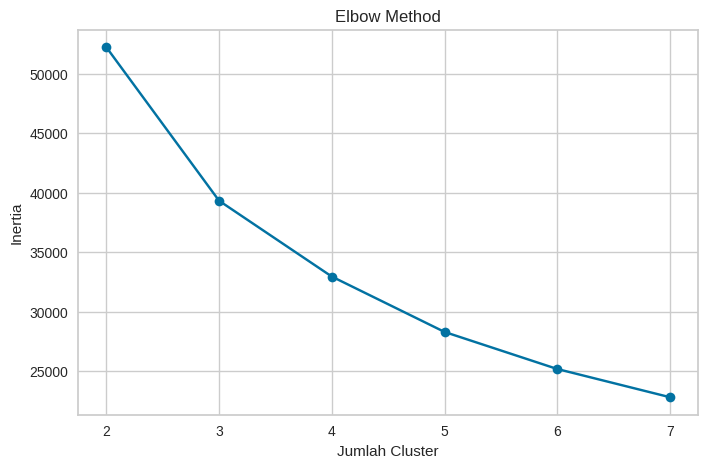

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
evaluation_result = []

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    cluster_temp = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, cluster_temp)
    davies_bouldin = davies_bouldin_score(X_scaled, cluster_temp)
    calinski_harabasz = calinski_harabasz_score(X_scaled, cluster_temp)

    evaluation_result.append({
        'k': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies_bouldin,
        'Calinski-Harabasz Score': calinski_harabasz
    })

evaluation_df = pd.DataFrame(evaluation_result)
evaluation_df

,k,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,2,0.406359,0.965548,18298.226965
1,3,0.324571,1.165630,15430.827829
2,4,0.279289,1.140427,13565.363706
3,5,0.276952,1.187308,12669.073403
4,6,0.267939,1.153499,11883.279868
5,7,0.274356,1.110048,11278.469719


In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20,
    max_iter=500
)

df2['Cluster'] = kmeans.fit_predict(X_scaled)
df2.head()

,Income,Age,Dependents,Occupation,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,...,Disposable_Income,Total_Expense,Expense_to_Income_Ratio,Essential_Ratio,Discretionary_Spending,Age_Group,Disposable_Income_Ratio,Loan_to_Income_Ratio,Discretionary_Ratio,Cluster
0,44637.24964,49,0,Self_Employed,13391.174890,0.000000,2206.490129,6658.768341,2636.970696,1651.801726,...,11265.627710,33371.62193,0.747618,0.598494,4019.511102,45-60,0.252382,0.000000,0.090048,1
1,26858.59659,34,2,Retired,5371.719318,0.000000,869.522617,2818.444460,1543.018778,649.378103,...,9676.818733,17181.77786,0.639712,0.440201,2263.854847,25-35,0.360288,0.000000,0.084288,0
2,50367.60508,35,1,Student,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,1513.814376,...,13891.450620,36476.15446,0.724199,0.520756,3865.492522,25-35,0.275801,0.091569,0.076746,1
3,101455.60020,21,0,Self_Employed,15218.340040,6567.855801,3597.595115,12929.092170,6714.626751,3646.170425,...,37601.469090,63854.13116,0.629380,0.478609,8581.911867,<25,0.370620,0.064736,0.084588,0
4,24875.28355,52,4,Professional,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,692.827225,...,6265.700532,18609.58302,0.748115,0.563599,1868.524377,45-60,0.251885,0.125129,0.075116,1


In [ ]:
silhouette = silhouette_score(X_scaled, df2['Cluster'])
davies_bouldin = davies_bouldin_score(X_scaled, df2['Cluster'])
calinski_harabasz = calinski_harabasz_score(X_scaled, df2['Cluster'])

print('Silhouette Score:', silhouette)
print('Davies-Bouldin Index:', davies_bouldin)
print('Calinski-Harabasz Score:', calinski_harabasz)

Silhouette Score: 0.32457098606100127
Davies-Bouldin Index: 1.165630245775491
Calinski-Harabasz Score: 15430.827829240412


In [ ]:
df2['Cluster'].value_counts()

,count
Cluster,
0,9017
1,6951
2,4032


In [ ]:
df2['Cluster'].value_counts(normalize=True) * 100

,proportion
Cluster,
0,45.085
1,34.755
2,20.160


In [ ]:
cluster_profile = df2.groupby('Cluster')[features_cluster].mean()
cluster_profile

,Expense_to_Income_Ratio,Essential_Ratio,Disposable_Income_Ratio,Loan_to_Income_Ratio,Discretionary_Ratio
Cluster,,,,,
0,0.658066,0.449893,0.341934,0.004177,0.088406
1,0.765046,0.547929,0.234954,0.043215,0.090142
2,0.868958,0.647206,0.131042,0.140438,0.091247


In [ ]:
profile_cols = [
    'Income',
    'Total_Expense',
    'Expense_to_Income_Ratio',
    'Disposable_Income',
    'Disposable_Income_Ratio',
    'Essential_Ratio',
    'Loan_to_Income_Ratio',
    'Discretionary_Ratio'
]

cluster_profile_detail = df2.groupby('Cluster')[profile_cols].mean()
cluster_profile_detail

,Income,Total_Expense,Expense_to_Income_Ratio,Disposable_Income,Disposable_Income_Ratio,Essential_Ratio,Loan_to_Income_Ratio,Discretionary_Ratio
Cluster,,,,,,,,
0,41884.868586,27672.809927,0.658066,14212.058660,0.341934,0.449893,0.004177,0.088406
1,39541.879730,30128.500481,0.765046,9413.379250,0.234954,0.547929,0.043215,0.090142
2,28403.268682,24649.853758,0.868958,3753.414924,0.131042,0.647206,0.140438,0.091247


In [ ]:
cluster_profile = df2.groupby('Cluster')[features_cluster].mean()

cluster_profile['Risk_Score'] = (
    cluster_profile['Expense_to_Income_Ratio'] +
    cluster_profile['Essential_Ratio'] +
    cluster_profile['Loan_to_Income_Ratio'] +
    cluster_profile['Discretionary_Ratio'] -
    cluster_profile['Disposable_Income_Ratio']
)

cluster_profile

,Expense_to_Income_Ratio,Essential_Ratio,Disposable_Income_Ratio,Loan_to_Income_Ratio,Discretionary_Ratio,Risk_Score
Cluster,,,,,,
0,0.658066,0.449893,0.341934,0.004177,0.088406,0.858608
1,0.765046,0.547929,0.234954,0.043215,0.090142,1.211378
2,0.868958,0.647206,0.131042,0.140438,0.091247,1.616807


In [ ]:
risk_order = cluster_profile['Risk_Score'].sort_values().index

risk_order

Index([0, 1, 2], dtype='int32', name='Cluster')

In [ ]:
label_mapping = {
    risk_order[0]: 'Financially Healthy',
    risk_order[1]: 'Moderate',
    risk_order[2]: 'At Risk'
}

label_mapping

{np.int32(0): 'Financially Healthy',
 np.int32(1): 'Moderate',
 np.int32(2): 'At Risk'}

In [ ]:
df2['Financial_Health_Label'] = df2['Cluster'].map(label_mapping)

df2[['Cluster', 'Financial_Health_Label']].head()

,Cluster,Financial_Health_Label
0,1,Moderate
1,0,Financially Healthy
2,1,Moderate
3,0,Financially Healthy
4,1,Moderate


In [ ]:
df2['Financial_Health_Label'].value_counts()

,count
Financial_Health_Label,
Financially Healthy,9017
Moderate,6951
At Risk,4032


In [ ]:
df2['Financial_Health_Label'].value_counts(normalize=True) * 100

,proportion
Financial_Health_Label,
Financially Healthy,45.085
Moderate,34.755
At Risk,20.160


In [ ]:
label_profile = df2.groupby('Financial_Health_Label')[profile_cols].mean()
label_profile

,Income,Total_Expense,Expense_to_Income_Ratio,Disposable_Income,Disposable_Income_Ratio,Essential_Ratio,Loan_to_Income_Ratio,Discretionary_Ratio
Financial_Health_Label,,,,,,,,
At Risk,28403.268682,24649.853758,0.868958,3753.414924,0.131042,0.647206,0.140438,0.091247
Financially Healthy,41884.868586,27672.809927,0.658066,14212.058660,0.341934,0.449893,0.004177,0.088406
Moderate,39541.879730,30128.500481,0.765046,9413.379250,0.234954,0.547929,0.043215,0.090142


In [ ]:
label_order = ['Financially Healthy', 'Moderate', 'At Risk']

label_profile = label_profile.loc[label_order]
label_profile

,Income,Total_Expense,Expense_to_Income_Ratio,Disposable_Income,Disposable_Income_Ratio,Essential_Ratio,Loan_to_Income_Ratio,Discretionary_Ratio
Financial_Health_Label,,,,,,,,
Financially Healthy,41884.868586,27672.809927,0.658066,14212.058660,0.341934,0.449893,0.004177,0.088406
Moderate,39541.879730,30128.500481,0.765046,9413.379250,0.234954,0.547929,0.043215,0.090142
At Risk,28403.268682,24649.853758,0.868958,3753.414924,0.131042,0.647206,0.140438,0.091247


In [ ]:
df2.to_csv('financial_health_labeled.csv', index=False)